# Part 1

In [100]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.ndimage import convolve1d
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA


import seaborn as sns
sns.set()


plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120

## 1) Visualize and preprocess the data for subject 2 (use only the first exercise set:  S2_A1_E1 with 12 actions). Does the data look reasonable? Did you need to remove any trials?

a) load the data

In [101]:
# Path to your parquet file
path = "data/s2/S2_A1_E1.parquet"

df = pd.read_parquet(path)

print(df.shape)
df.head()

(100686, 36)


,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,emg_9,...,glove_16,glove_17,glove_18,glove_19,glove_20,glove_21,repetition_0,rerepetition_0,stimulus_0,restimulus_0
0,0.0269,0.1001,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
1,0.0269,0.0757,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
2,0.0317,0.0586,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
3,0.0293,0.0391,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
4,0.0293,0.0269,0.0024,0.0024,0.0049,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0


In [102]:
print(df.columns.tolist())

['emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5', 'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2', 'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8', 'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14', 'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20', 'glove_21', 'repetition_0', 'rerepetition_0', 'stimulus_0', 'restimulus_0']


b) Preprocess data

In [103]:
emg_cols   = [c for c in df.columns if c.startswith("emg_")]
glove_cols = [c for c in df.columns if c.startswith("glove_")]

emg        = df[emg_cols].to_numpy()
glove      = df[glove_cols].to_numpy()

stimulus      = df["stimulus_0"].to_numpy().astype(int)
restimulus    = df["restimulus_0"].to_numpy().astype(int)
repetition    = df["repetition_0"].to_numpy().astype(int)
rerepetition  = df["rerepetition_0"].to_numpy().astype(int)

n_samples, n_channels = emg.shape
print(f"EMG shape: {emg.shape}, glove shape: {glove.shape}")


EMG shape: (100686, 10), glove shape: (100686, 22)


In [104]:
fs = 100 
t = np.arange(n_samples) / fs
print(f"Approx recording duration: {t[-1]:.1f} s")

Approx recording duration: 1006.9 s


## 1. Quick sanity plots (raw EMG + glove)

### 1a. EMG channels over a short window

Text(0.5, 1.02, 'Raw EMG, 5 s window')

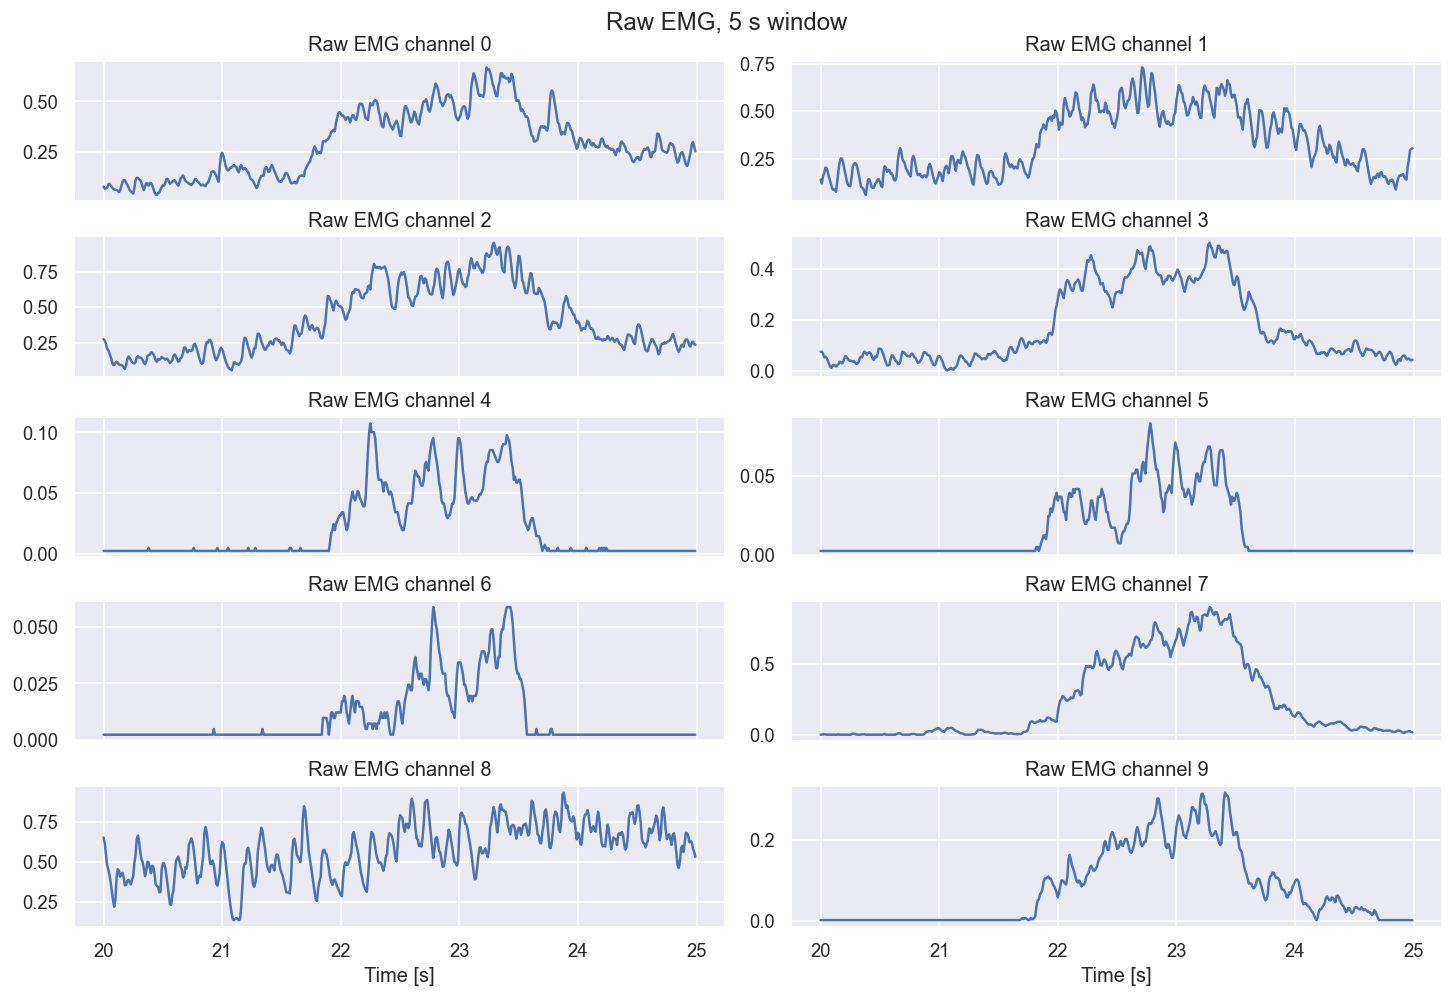

In [105]:
# pick a 5 s window somewhere in the middle
window_duration = 5  # seconds
start_time = 20      # seconds (you can change this)
start_idx = int(start_time * fs)
end_idx   = int((start_time + window_duration) * fs)
end_idx   = min(end_idx, n_samples)

segment_t   = t[start_idx:end_idx]
segment_emg = emg[start_idx:end_idx, :]

fig, ax = plt.subplots(5, 2, sharex=True, figsize=(12, 8), constrained_layout=True)
ax = ax.ravel()

for ch in range(n_channels):
    ax[ch].plot(segment_t, segment_emg[:, ch])
    ax[ch].set_title(f"Raw EMG channel {ch}")
    if ch >= 8:
        ax[ch].set_xlabel("Time [s]")

fig.suptitle("Raw EMG, 5 s window", y=1.02)


### 1b. A few glove sensors in the same window

Text(0.5, 1.02, 'Glove signals, same 5 s window')

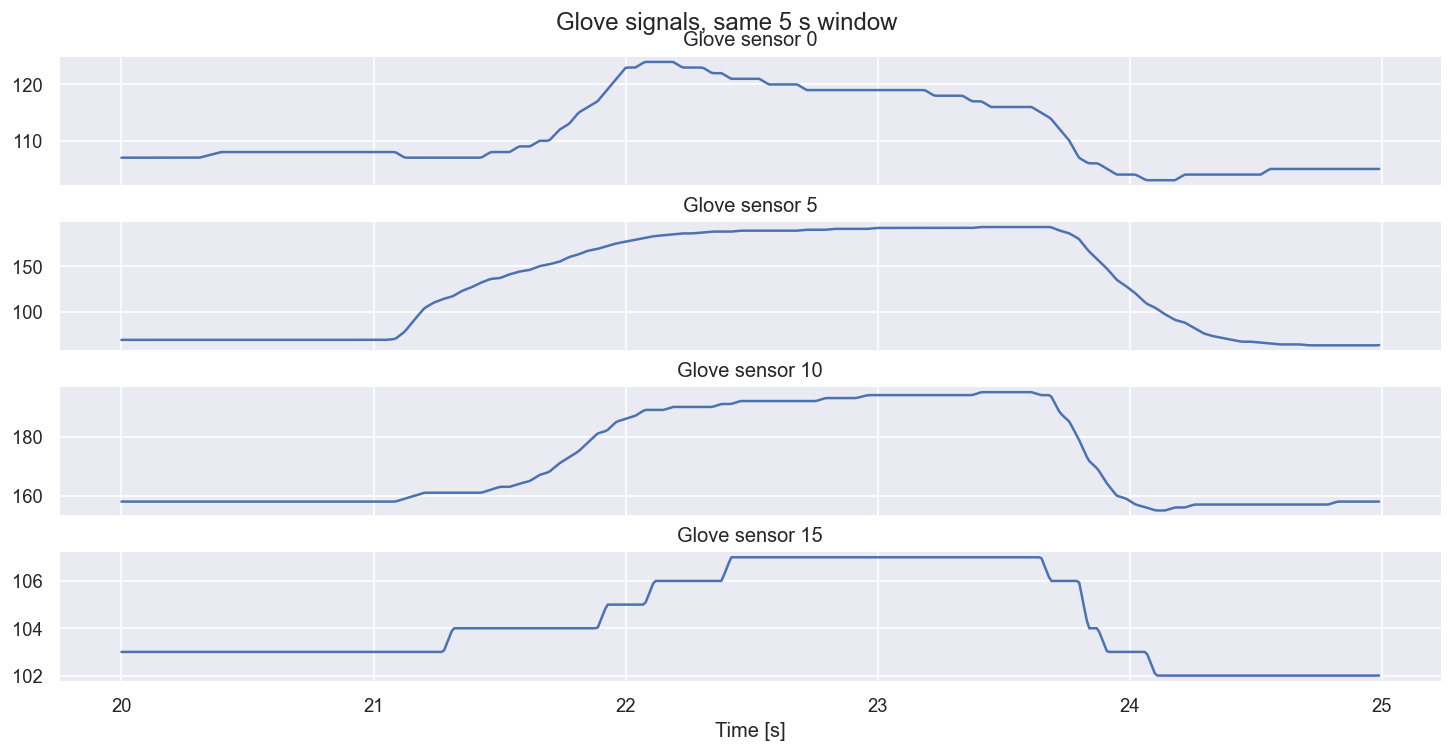

In [106]:
segment_glove = glove[start_idx:end_idx, :]

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

for i, gch in enumerate([0, 5, 10, 15]):
    ax[i].plot(segment_t, segment_glove[:, gch])
    ax[i].set_title(f"Glove sensor {gch}")
ax[-1].set_xlabel("Time [s]")

fig.suptitle("Glove signals, same 5 s window", y=1.02)


## 2. What preprocessing is already done for this dataset?

Otto Bock electrodes:

1) amplified (14'000)
2) band-pass filtered (range: TODO)
3) RMS-recitfied EMG 
4) internal shielding & filtering against 50-60 Hz power supply, mobile phones, etc.  

### 2a. Check for 50 Hz artifacts

Text(0.5, 1.05, 'Power spectral density – check for 50 Hz artifact')

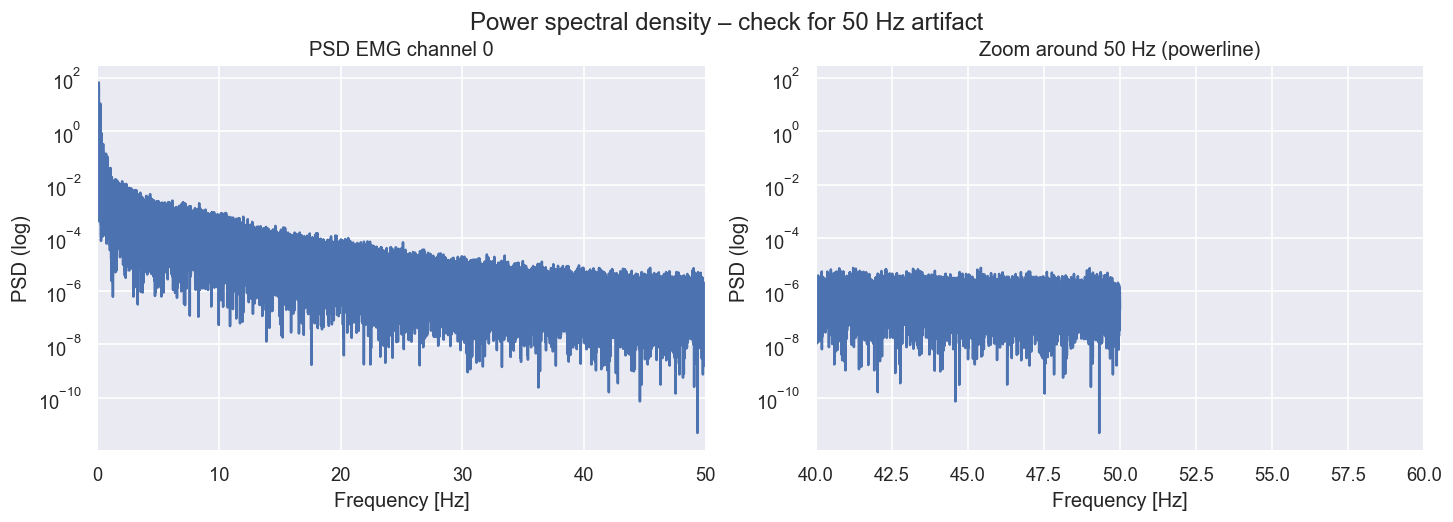

In [107]:
from scipy.signal import welch

channel_for_psd = 0  # you can change this

f, Pxx = welch(emg[:, channel_for_psd], fs=fs, nperseg=len(emg))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Full band 0–50 Hz (fs/2)
ax[0].semilogy(f, Pxx)
ax[0].set_xlim(0, fs / 2)
ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel("PSD (log)")
ax[0].set_title(f"PSD EMG channel {channel_for_psd}")

# Zoom around 50 Hz
ax[1].semilogy(f, Pxx)
ax[1].set_xlim(40, 60)
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("PSD (log)")
ax[1].set_title("Zoom around 50 Hz (powerline)")

fig.suptitle("Power spectral density – check for 50 Hz artifact", y=1.05)


### 2b. Check that it's rectified (can already see above)

Global min / max per channel:
[0.0024 0.0024 0.0024 0.0024 0.0024 0.     0.     0.0024 0.     0.0024]
[3.8647 2.1606 1.3599 2.9883 0.5298 0.6421 0.5298 2.8076 4.6606 2.0508]


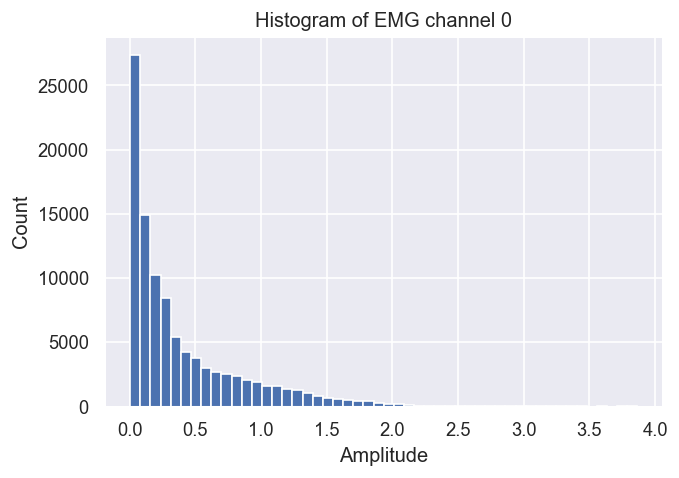

In [108]:
print("Global min / max per channel:")
print(np.min(emg, axis=0))
print(np.max(emg, axis=0))

plt.figure(figsize=(6,4))
plt.hist(emg[:, 0], bins=50)
plt.title("Histogram of EMG channel 0")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.show()


### 3. Understand trial structure

In [109]:
unique_restim = np.unique(restimulus)
print("Unique restimulus labels:", unique_restim)

actions = unique_restim[unique_restim > 0]  # exclude rest (0)
print(f"Number of actions (excluding rest): {len(actions)}")

unique_reps = np.unique(rerepetition)
unique_reps = unique_reps[unique_reps > 0]
print("Unique rerepetition labels:", unique_reps)
print(f"Number of repetitions (excluding 0): {len(unique_reps)}")

n_stimuli     = len(actions)
n_repetitions = len(unique_reps)
samples_per_trial = np.zeros((n_stimuli, n_repetitions), dtype=int)

for i, a in enumerate(actions):
    for j, r in enumerate(unique_reps):
        idx = (restimulus == a) & (rerepetition == r)
        samples_per_trial[i, j] = idx.sum()

samples_per_trial



Unique restimulus labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Number of actions (excluding rest): 12
Unique rerepetition labels: [ 1  2  3  4  5  6  7  8  9 10]
Number of repetitions (excluding 0): 10


array([[307, 390, 262, 226, 418, 204, 196, 270, 306, 489],
       [334, 323, 344, 309, 333, 376, 362, 307, 348, 339],
       [465, 352, 450, 460, 436, 389, 323, 388, 383, 316],
       [310, 402, 357, 396, 255, 333, 263, 369, 438, 471],
       [516, 382, 425, 379, 463, 411, 387, 343, 286, 377],
       [337, 319, 337, 368, 338, 336, 268, 354, 319, 313],
       [428, 392, 341, 393, 421, 445, 342, 328, 329, 358],
       [289, 372, 406, 397, 498, 336, 415, 328, 472, 405],
       [384, 424, 371, 316, 280, 314, 342, 284, 307, 421],
       [311, 296, 299, 296, 301, 246, 213, 317, 493, 221],
       [352, 403, 338, 416, 330, 355, 313, 322, 329, 219],
       [270, 330, 300, 387, 295, 204, 363, 267, 281, 329]])

Looks correct (trial length do differ a lot but I hope that's fine)

### 4a. Visual trial inspection

In [110]:
def plot_trial_emg(action_id, rep_id, signal=None, title_prefix="EMG"):
    if signal is None:
        signal = emg
        
    idx = (restimulus == action_id) & (rerepetition == rep_id)
    trial = signal[idx, :]
    if trial.size == 0:
        print("No samples for this (action, repetition).")
        return
    
    n_ch = trial.shape[1]
    rows, cols = 5, 2  # for 10 channels
    
    fig, ax = plt.subplots(rows, cols, figsize=(12, 8), constrained_layout=True, sharex=True)
    ax = ax.ravel()
    
    for ch in range(n_ch):
        ax[ch].plot(trial[:, ch])
        ax[ch].set_title(f"ch {ch}")
    for k in range(n_ch, rows * cols):
        ax[k].axis("off")
    
    fig.suptitle(f"{title_prefix} – action {action_id}, repetition {rep_id}", y=1.02)


Manually check a few

actions[0]: first non-zero restimulus label (first of 12 movements)

unique_reps[0]: repetition 1

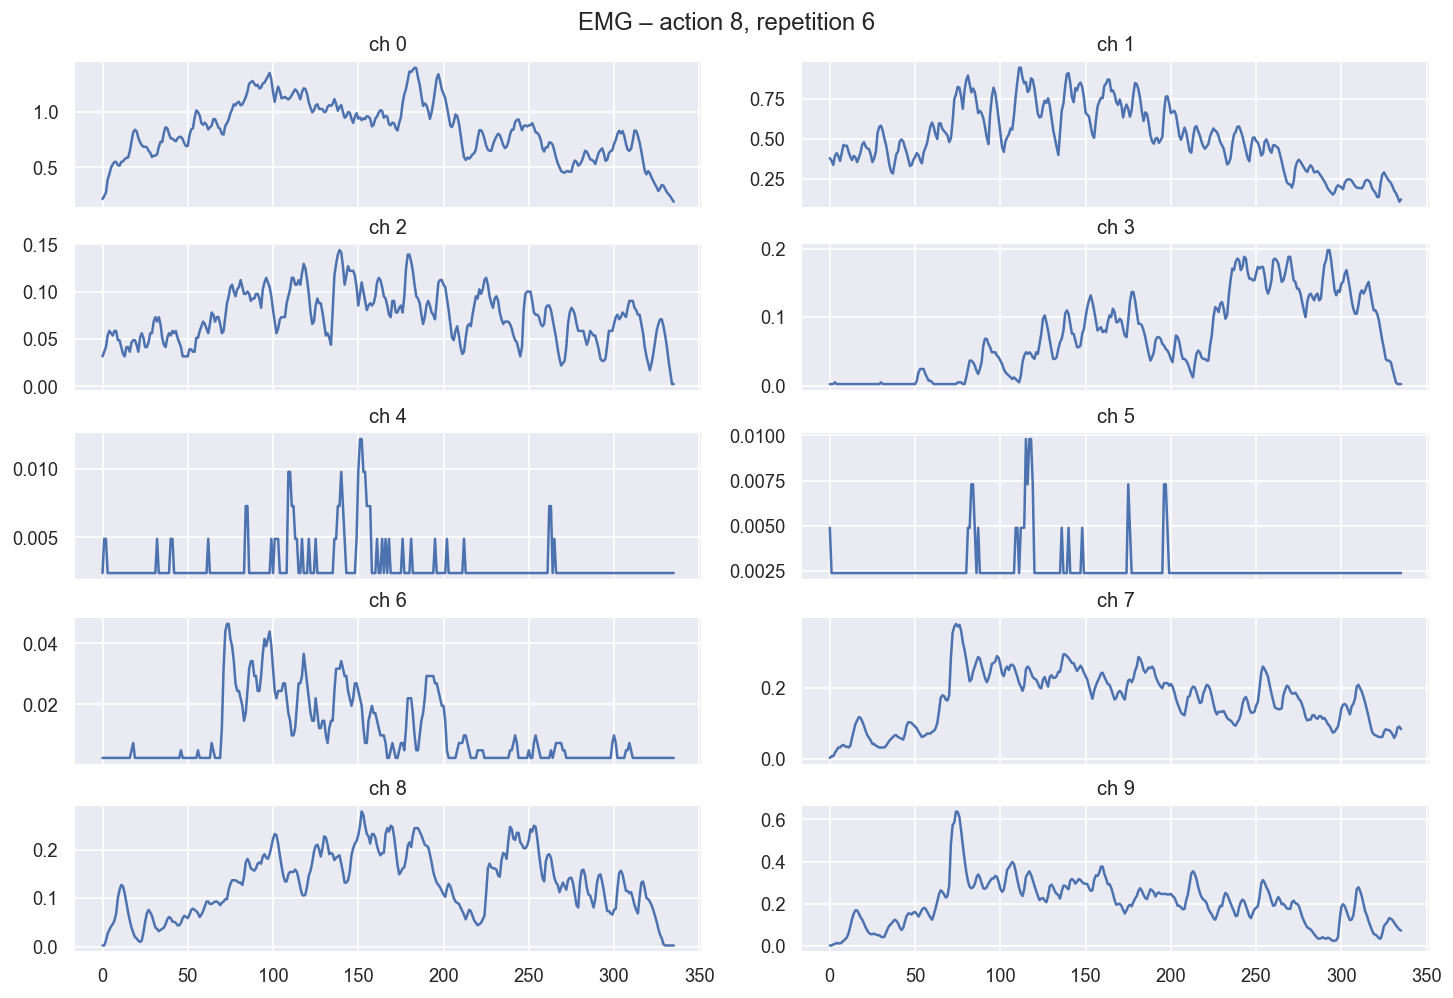

In [111]:
# Example: first action, first repetition
plot_trial_emg(action_id=actions[7], rep_id=unique_reps[5])


### 4b. Visual trial inspection (same scale)

In [112]:
def plot_trial_emg_same_scale(action_id, rep_id, signal=None, title_prefix="EMG"):
    if signal is None:
        signal = emg

    # Select trial samples
    idx = (restimulus == action_id) & (rerepetition == rep_id)
    trial = signal[idx, :]
    if trial.size == 0:
        print("No samples for this (action, repetition).")
        return

    n_ch = trial.shape[1]
    rows, cols = 5, 2

    # Compute global y-limits across all channels
    y_min = trial.min()
    y_max = trial.max()

    fig, ax = plt.subplots(rows, cols, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
    ax = ax.ravel()

    for ch in range(n_ch):
        ax[ch].plot(trial[:, ch])
        ax[ch].set_title(f"ch {ch}")
        ax[ch].set_ylim(y_min, y_max)  # same scale for all plots

    # Hide unused subplots (for generality)
    for k in range(n_ch, rows * cols):
        ax[k].axis("off")

    fig.suptitle(f"{title_prefix} (same y-scale) – action {action_id}, repetition {rep_id}", y=1.02)


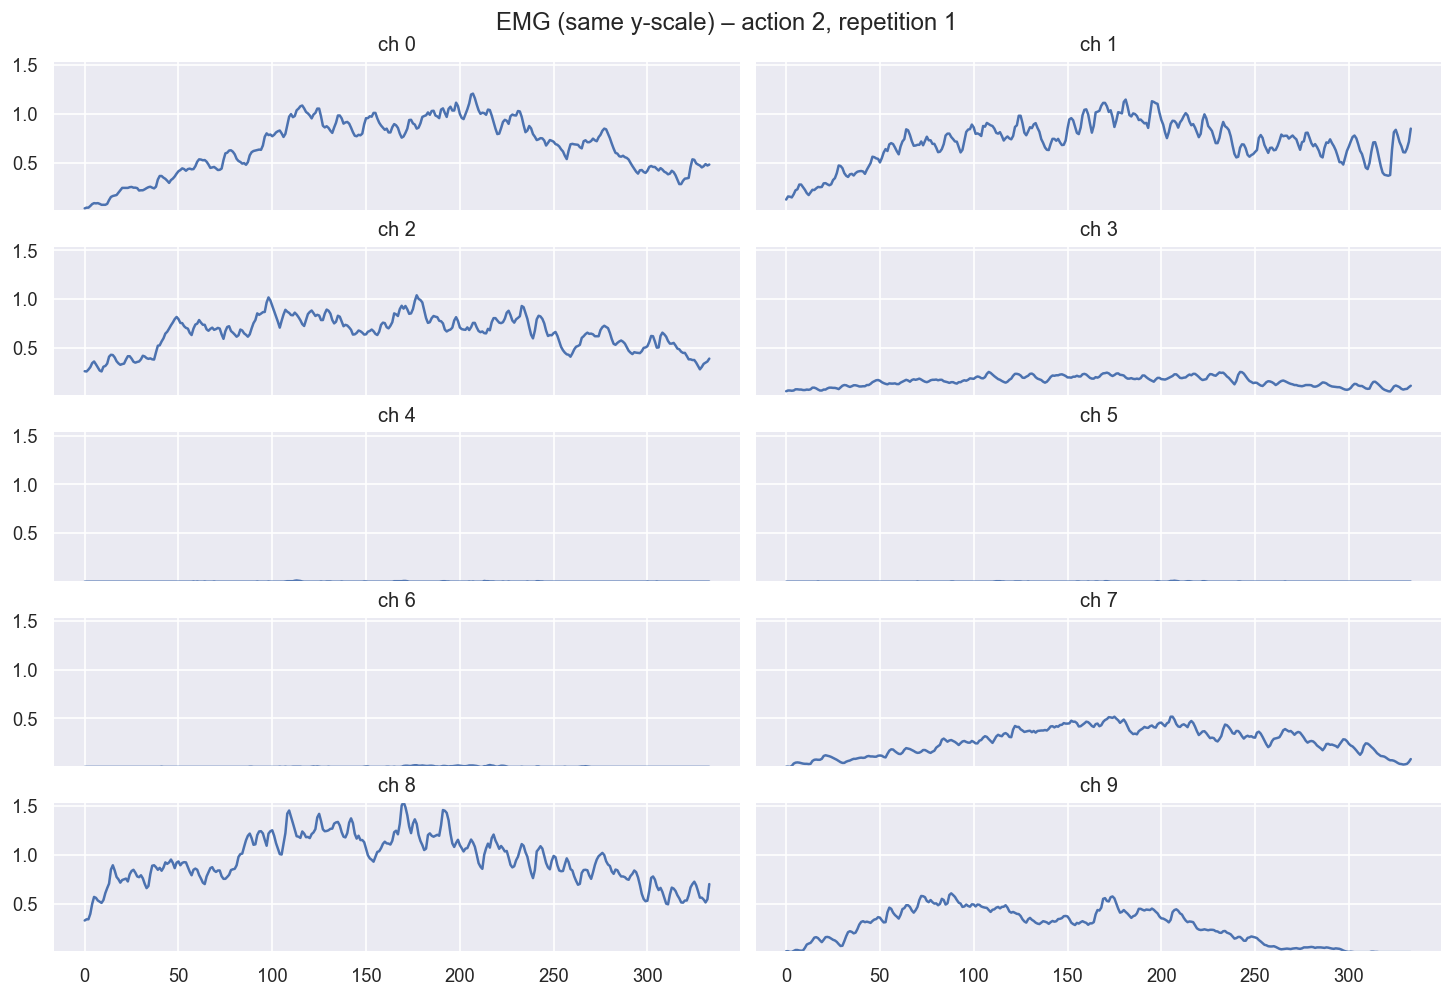

In [113]:
plot_trial_emg_same_scale(action_id=actions[1], rep_id=unique_reps[0])

Check the last one (maybe some sensor lost contact)

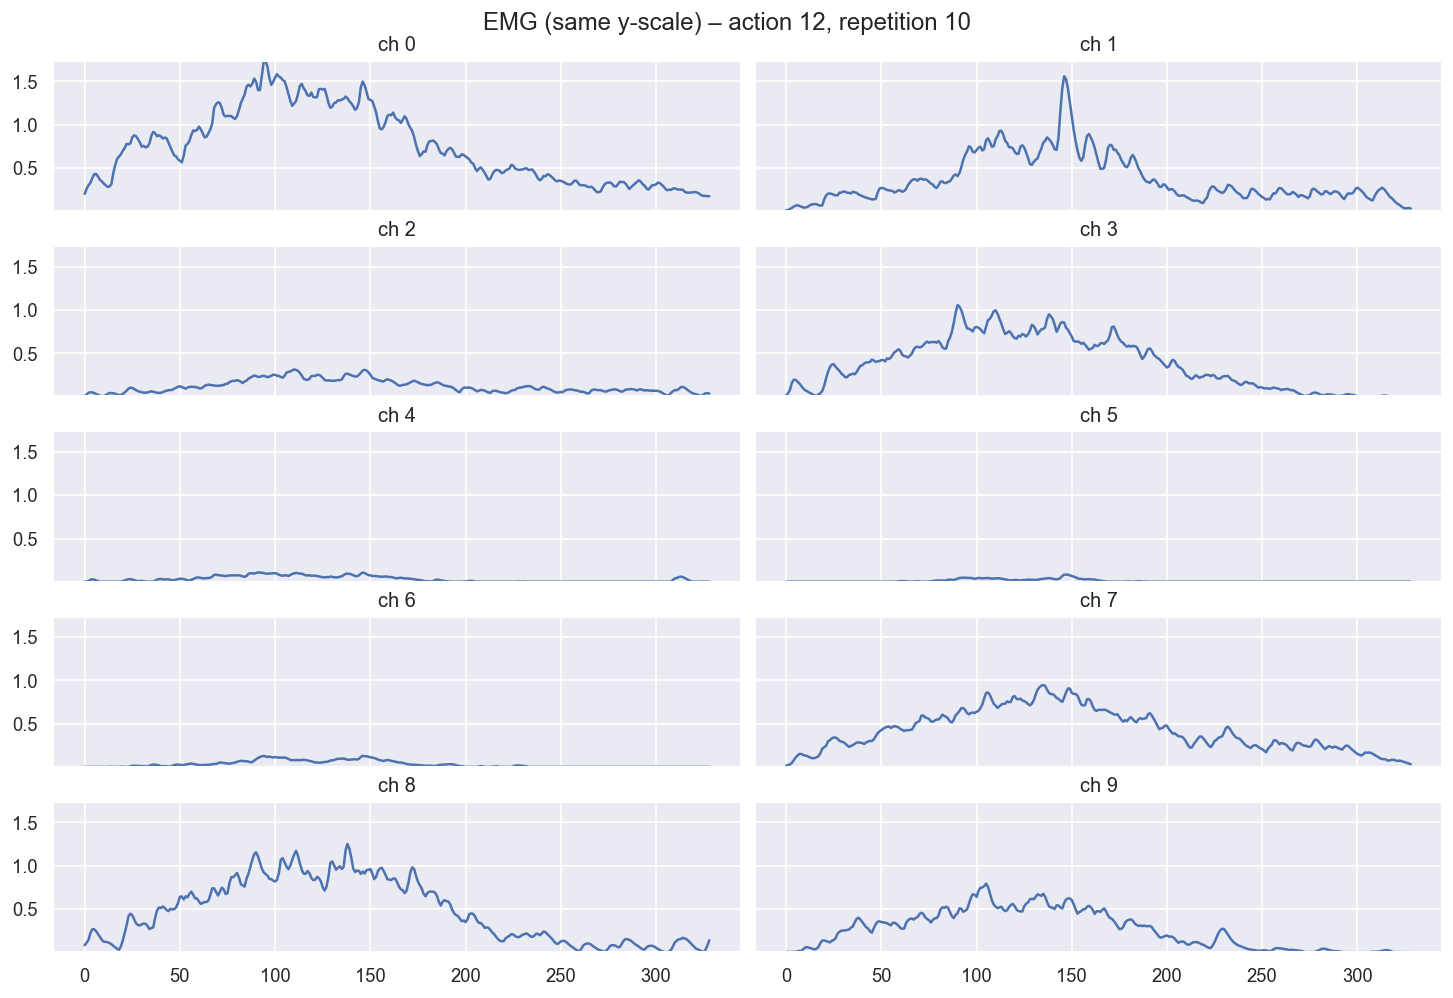

In [114]:
plot_trial_emg_same_scale(action_id=actions[11], rep_id=unique_reps[9])

Doing this manually is kind of tedious and I ain't doing that

12 actions, 10 repetitions --> 120 plots 

### 5a. Automatic detection

In [115]:
def find_bad_trials(
    signal, 
    restimulus, 
    rerepetition, 
    actions, 
    reps, 
    rms_drop_fraction=0.1, 
    min_std=1e-7
):
    """
    Flag (action, repetition) trials where one or more channels are basically 'dead':
      - very low RMS compared to typical (global RMS), and/or
      - almost zero variance.

    Parameters
    ----------
    signal : np.ndarray
        EMG array of shape (N_samples, N_channels).
    restimulus, rerepetition : np.ndarray
        Label vectors.
    actions, reps : array-like
        Unique action and repetition labels (exclude 0).
    rms_drop_fraction : float
        Trial RMS must be at least this fraction of global RMS, otherwise it's suspicious.
    min_std : float
        Absolute minimum standard deviation to avoid being considered 'flat'.

    Returns
    -------
    bad_trials : list of dict
        Each dict has keys: 'action', 'repetition', 'bad_channels', 'trial_length'.
    """
    bad_trials = []

    # Global RMS per channel over the full recording
    global_rms = np.sqrt(np.mean(signal**2, axis=0))

    for a in actions:
        for r in reps:
            idx = (restimulus == a) & (rerepetition == r)
            trial = signal[idx, :]
            if trial.size == 0:
                continue

            # Trial-level RMS and std per channel
            trial_rms = np.sqrt(np.mean(trial**2, axis=0))
            trial_std = trial.std(axis=0)

            # Conditions for 'bad' channels
            low_amp = trial_rms < (rms_drop_fraction * global_rms)
            flat    = trial_std < min_std

            bad_ch = np.where(low_amp | flat)[0]

            if len(bad_ch) > 0:
                bad_trials.append({
                    "action": int(a),
                    "repetition": int(r),
                    "bad_channels": bad_ch.tolist(),
                    "trial_length": int(trial.shape[0])
                })

    return bad_trials


In [117]:
bad_trials = find_bad_trials(
    signal=emg,
    restimulus=restimulus,
    rerepetition=rerepetition,
    actions=actions,
    reps=unique_reps,
    rms_drop_fraction=0.02,  # ~10% of normal RMS
    min_std=1e-7          # almost flat
)

print(f"Number of suspicious trials: {len(bad_trials)}")
bad_trials[:40]  # show first few


Number of suspicious trials: 0


[]

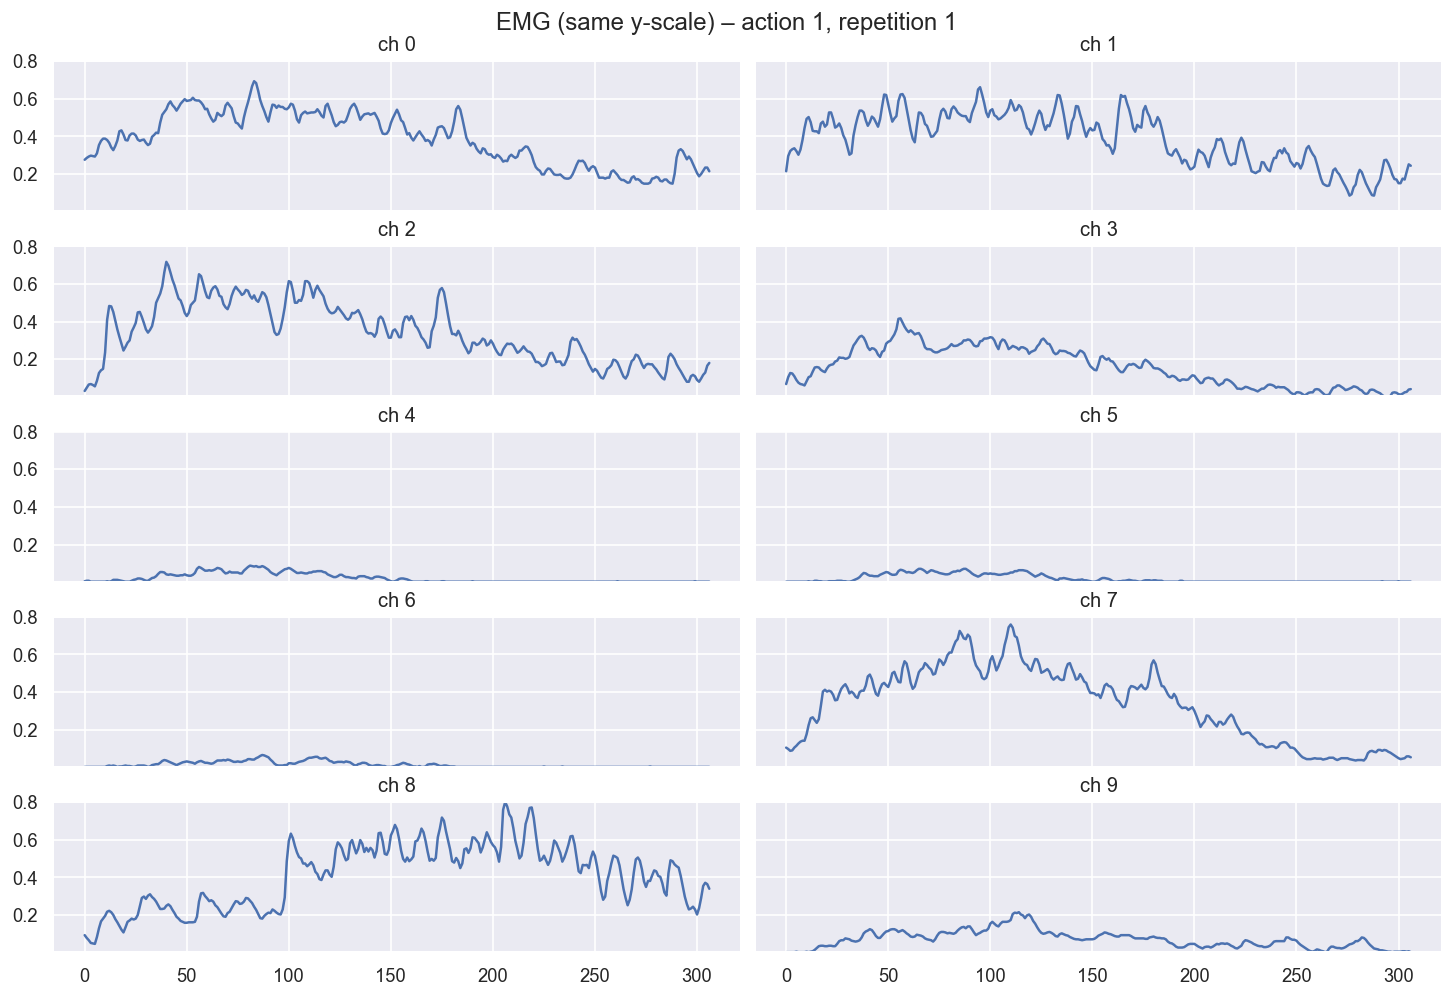

In [140]:
plot_trial_emg_same_scale(action_id=actions[0], rep_id=unique_reps[0])

### 5b. Exclude those bad channels (only that action of course)

In [119]:
# 1) Turn bad_trials into a set of (action, repetition) pairs
trials_to_drop = {(b["action"], b["repetition"]) for b in bad_trials}
print("Trials to drop (action, repetition):", sorted(trials_to_drop))

# 2) Build a sample-wise mask: keep everything *except* those trials
def build_keep_mask(restimulus, rerepetition, trials_to_drop):
    mask = np.ones_like(restimulus, dtype=bool)
    for (a, r) in trials_to_drop:
        mask &= ~((restimulus == a) & (rerepetition == r))
    return mask

keep_mask = build_keep_mask(restimulus, rerepetition, trials_to_drop)

print("Original samples:", len(df))
print("Samples after dropping:", keep_mask.sum())

# 3) New cleaned DataFrame
df_clean = df[keep_mask].reset_index(drop=True)

# 4) Re-derive cleaned arrays from df_clean
emg_clean   = df_clean[emg_cols].to_numpy()
glove_clean = df_clean[glove_cols].to_numpy()

restimulus_clean   = df_clean["restimulus_0"].to_numpy().astype(int)
rerepetition_clean = df_clean["rerepetition_0"].to_numpy().astype(int)

print("Clean EMG shape:", emg_clean.shape)
print("Clean restimulus unique:", np.unique(restimulus_clean))
print("Clean rerepetition unique:", np.unique(rerepetition_clean))



Trials to drop (action, repetition): []
Original samples: 100686
Samples after dropping: 100686
Clean EMG shape: (100686, 10)
Clean restimulus unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Clean rerepetition unique: [ 0  1  2  3  4  5  6  7  8  9 10]


### 6. Envelopes

In [120]:
# Number of stimuli and repetitions in the CLEANED labels
actions_clean = np.unique(restimulus_clean)
actions_clean = actions_clean[actions_clean > 0]  # exclude rest

reps_clean = np.unique(rerepetition_clean)
reps_clean = reps_clean[reps_clean > 0]          # exclude 0

n_stimuli_clean     = len(actions_clean)
n_repetitions_clean = len(reps_clean)
n_channels          = emg_clean.shape[1]

print("n_stimuli_clean:", n_stimuli_clean)
print("n_repetitions_clean:", n_repetitions_clean)

# Moving-average window (same as Exercise 10b)
mov_mean_length  = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

# Nested lists: [stimulus_idx][repetition_idx]
emg_windows_clean   = [[None for _ in range(n_repetitions_clean)] for _ in range(n_stimuli_clean)]
emg_envelopes_clean = [[None for _ in range(n_repetitions_clean)] for _ in range(n_stimuli_clean)]

for s_idx, a in enumerate(actions_clean):
    for r_idx, r in enumerate(reps_clean):
        # select this trial in the CLEANED data
        idx = (restimulus_clean == a) & (rerepetition_clean == r)
        trial = emg_clean[idx, :]
        if trial.size == 0:
            continue

        emg_windows_clean[s_idx][r_idx]   = trial
        emg_envelopes_clean[s_idx][r_idx] = convolve1d(trial, mov_mean_weights, axis=0)


n_stimuli_clean: 12
n_repetitions_clean: 10


Quickly look at envelope for one trial

Text(0.5, 0.98, 'Envelopes of the EMG signal')

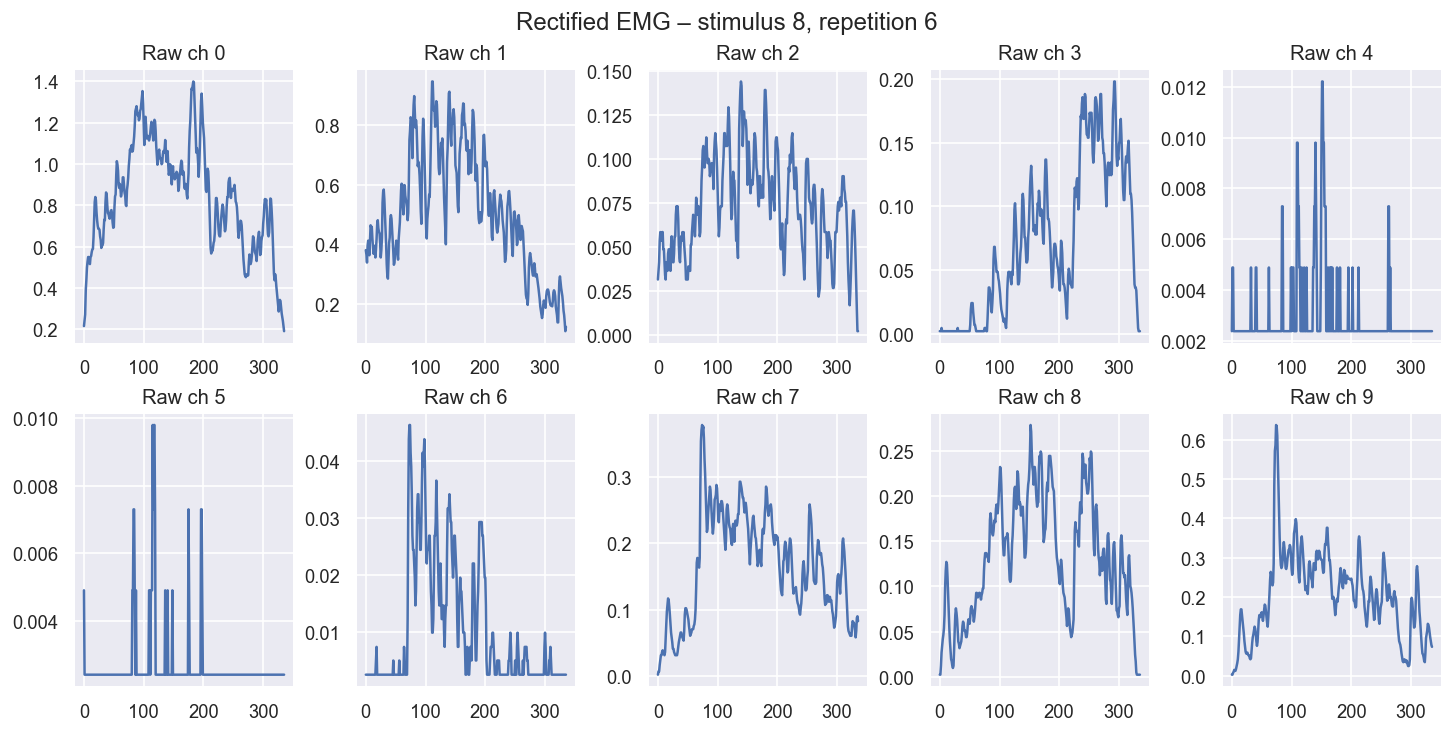

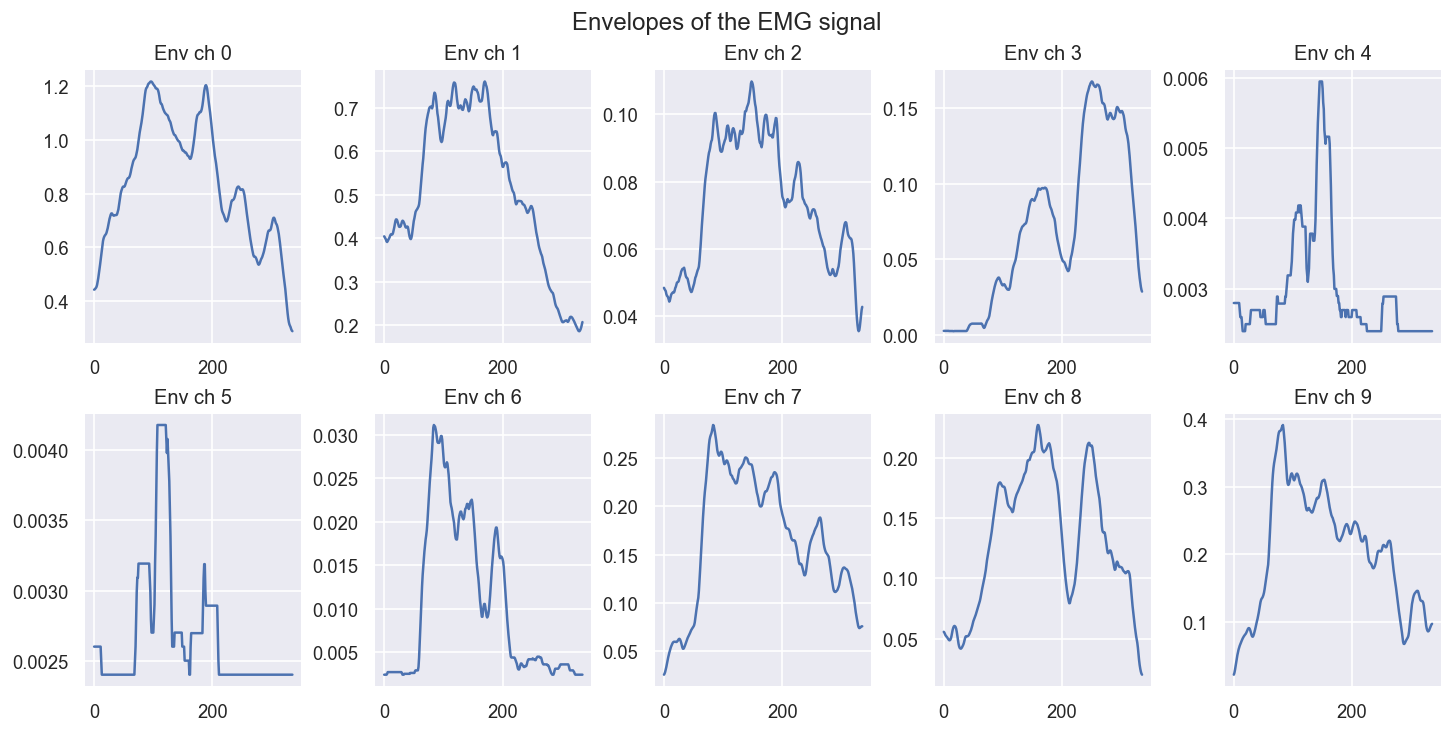

In [121]:
example_s_idx = 7  # first stimulus in actions_clean
example_r_idx = 5  # first repetition in reps_clean

trial_raw  = emg_windows_clean[example_s_idx][example_r_idx]
trial_env  = emg_envelopes_clean[example_s_idx][example_r_idx]

fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()

for ch in range(n_channels):
    ax[ch].plot(trial_raw[:, ch])
    ax[ch].set_title(f"Raw ch {ch}")
plt.suptitle(f"Rectified EMG – stimulus {actions_clean[example_s_idx]}, repetition {reps_clean[example_r_idx]}")

fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()
for ch in range(n_channels):
    ax[ch].plot(trial_env[:, ch])
    ax[ch].set_title(f"Env ch {ch}")
plt.suptitle("Envelopes of the EMG signal")


### 7 Average activations + heatmaps

In [122]:
import seaborn as sns
sns.set()

# (channels, stimuli, repetitions)
emg_average_activations_clean = np.full(
    (n_channels, n_stimuli_clean, n_repetitions_clean),
    np.nan
)

for s_idx in range(n_stimuli_clean):
    for r_idx in range(n_repetitions_clean):
        env = emg_envelopes_clean[s_idx][r_idx]
        if env is None:
            continue
        emg_average_activations_clean[:, s_idx, r_idx] = np.mean(env, axis=0)


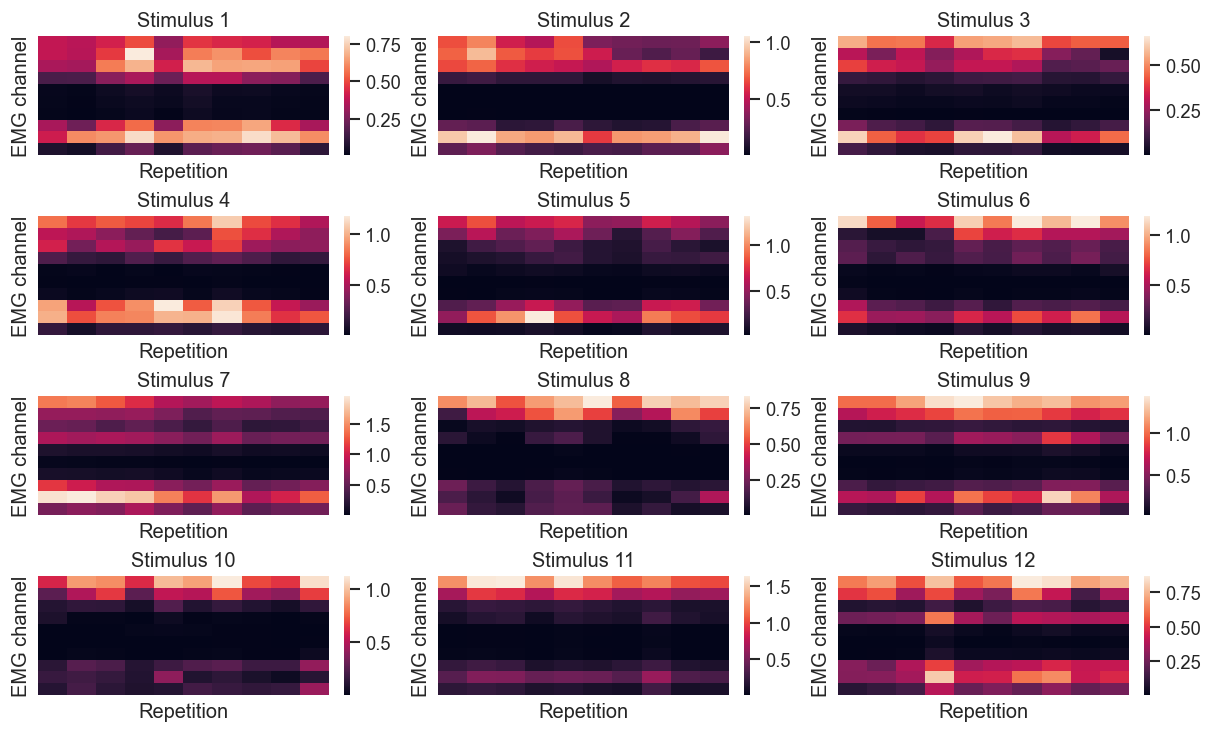

In [123]:
fig, ax = plt.subplots(4, 3, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for s_idx in range(n_stimuli_clean):
    sns.heatmap(
        emg_average_activations_clean[:, s_idx, :],
        ax=ax[s_idx],
        xticklabels=False,
        yticklabels=False,
        cbar=True
    )
    ax[s_idx].set_title(f"Stimulus {actions_clean[s_idx]}")
    ax[s_idx].set_xlabel("Repetition")
    ax[s_idx].set_ylabel("EMG channel")


## 2. Split the data into training, validation, and testing sets for the subject. Why do we need the different datasets? 

Things to keep in mind

- Stratified (The split should be stratified, meaning that all classes (movement labels) appear in train/validation/test in similar proportions.)

- We will fix a random seed to make the split reproducible.

- assign whole repetitions to each set, not individual windows (DATA LEAKAGE!!)

TODO: double check this (is that what they write in the paper?)

Let's split the following way:

2 repetitions (3 and 7) for testing --> 8 left for validation and training --> 4 fold cross validation

TODO do we have to be careful because we removed some channels for certain stimuli?

In [124]:
# For reproducibility when we shuffle reps later
np.random.seed(42)

# Unique repetitions in the CLEANED data (excluding 0)
all_reps = np.unique(rerepetition_clean)
all_reps = all_reps[all_reps > 0]

print("All repetitions in cleaned data:", all_reps)

# --- Choose which repetitions are test ---
# You can change [3, 7] if you prefer different test reps,
# but keep them fixed once chosen.
test_reps = np.array([3, 7])

# Training/validation repetitions are all others
train_reps = np.array([r for r in all_reps if r not in test_reps])

print("Train repetitions:", train_reps)
print("Test repetitions: ", test_reps)

# --- Sample-wise masks (for later use) ---
train_mask = np.isin(rerepetition_clean, train_reps)
test_mask  = np.isin(rerepetition_clean, test_reps)

print("Samples in train reps:", train_mask.sum())
print("Samples in test reps: ", test_mask.sum())


All repetitions in cleaned data: [ 1  2  3  4  5  6  7  8  9 10]
Train repetitions: [ 1  2  4  5  6  8  9 10]
Test repetitions:  [3 7]
Samples in train reps: 33774
Samples in test reps:  8017


In [125]:
# Optional: train/test views of the raw signals (per sample)
emg_train = emg_clean[train_mask]
emg_test  = emg_clean[test_mask]

restimulus_train = restimulus_clean[train_mask]
restimulus_test  = restimulus_clean[test_mask]

rerepetition_train = rerepetition_clean[train_mask]
rerepetition_test  = rerepetition_clean[test_mask]


In [126]:
unique_train_reps = np.unique(train_reps)
print("Unique train reps:", unique_train_reps)

# 4-fold CV over train repetitions
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# We'll store folds as lists of repetition IDs (not sample indices yet)
cv_rep_splits = []

for fold_idx, (rep_tr_idx, rep_val_idx) in enumerate(kf.split(unique_train_reps)):
    reps_in_train_fold = unique_train_reps[rep_tr_idx]
    reps_in_val_fold   = unique_train_reps[rep_val_idx]

    cv_rep_splits.append((reps_in_train_fold, reps_in_val_fold))

    print(f"Fold {fold_idx}:")
    print("  train reps:", reps_in_train_fold)
    print("  val reps  :", reps_in_val_fold)


Unique train reps: [ 1  2  4  5  6  8  9 10]
Fold 0:
  train reps: [ 1  4  5  6  9 10]
  val reps  : [2 8]
Fold 1:
  train reps: [2 4 5 6 8 9]
  val reps  : [ 1 10]
Fold 2:
  train reps: [ 1  2  5  8  9 10]
  val reps  : [4 6]
Fold 3:
  train reps: [ 1  2  4  6  8 10]
  val reps  : [5 9]


### Why we need all of that (ChatGPT) TODO

### ✅ Why do we need different datasets?

- **Training set** – used to fit the model.  
- **Validation set** – used for hyperparameter tuning and monitoring overfitting.  
- **Test set** – kept completely unseen; provides an unbiased estimate of generalization.

- **Repetition-wise splitting is essential for EMG:**  
  - Samples from the same repetition are highly correlated.  
  - Mixing repetitions across train/test causes information leakage and inflated accuracy.

- **A single split is not reliable:**  
  - Performance may vary depending on which repetitions land in each set.  
  - Cross-validation reduces this randomness.

---

### ✅ Why use cross-validation?

- Splits the training set into *k* folds.  
- Trains on *k−1* folds and validates on the remaining fold.  
- Repeats this *k* times and averages performance.

**Benefits:**

- More stable and trustworthy evaluation.  
- Helps detect overfitting.  
- Enables systematic hyperparameter tuning.  
- **Repetition-wise CV** ensures each repetition stays in exactly one fold — the correct approach for EMG data.


## 3. Extract features from the trials (at least 5 different ones), explain briefly why you picked these features. Visualize the typical values of  the features across the different trials. What do you see? Are the values similar  between repetitions and between channels? Explain the possible reasons for  similarity/discrepancies.  

### Challenge:

How to decide which features to use: see Feature importance/selection section in exercise 11

--> [mutual_info_classif](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_selection.mutual_info_classif.html) and [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html) from sklearn

Mutual_info_classif evaluates the mutual information between each feature and the target variable, providing an insight into the relevance of each feature. 

Meanwhile, SelectKBest allows us to select a specified number of features that have the highest scores according to a given scoring function, in this case, the mutual information.  
By combining these two functions, we can effectively reduce the feature space to those most relevant.

In exercise 11 they suggest to use frequency domain features --> find explanation why that's a good idea TODO

For more information, see (from exercise 11): 
PDFs on github

1. [Real-Time EMG Based Pattern Recognition Control for Hand Prostheses: A Review on Existing Methods, Challenges and Future Implementation](https://doi.org/10.3390/s19204596)
2. [Evaluation of the forearm EMG signal features for the control of a prosthetic hand](https://doi.org/10.1088/0967-3334/24/2/307)


1. "The results indicate that the energy of wavelet coefficients in nine scales and cepstrum
coefficients, which were selected in the evaluation procedure, lead to the best features"

2. "Hudgins [34] proposed the four
 different time-domain features (MAV, WL, ZC, SSC) [35] for feature extraction from EMG, and it is
 the most adopted one to date in the field of myoelectric pattern recognition"

In exercise 11 they use:

- MAV (Mean absolute value)

- WL (Waveform length)

- SSC (Slope sign changes)

- RMS (root mean square)

- STD (standard deviation)

- MAXAV (maximum absolute value)

### For now only time domain features

Note: apparently the two features from the first study are more difficult to implement. Could try that later or first try total spectral power or mean/median frequency TODO

In [127]:
# ==== Time-domain feature functions (per trial) ====
# Input:  trial array x with shape (T, n_channels)
# Output: 1D array of length n_channels (one value per channel)

import numpy as np

def feat_mav(x):
    """Mean Absolute Value (MAV)"""
    return np.mean(np.abs(x), axis=0)

def feat_rms(x):
    """Root Mean Square (RMS)"""
    return np.sqrt(np.mean(x**2, axis=0))

def feat_wl(x):
    """Waveform Length (WL)"""
    return np.sum(np.abs(np.diff(x, axis=0)), axis=0)

def feat_zc(x, thr=0.01):
    """
    Zero Crossings (ZC) with threshold.
    Counts sign changes where the amplitude change is larger than 'thr'.
    """
    x1 = x[:-1, :]
    x2 = x[1:, :]
    sign_change = (x1 * x2) < 0
    big_enough  = np.abs(x1 - x2) > thr
    return np.sum(sign_change & big_enough, axis=0)

def feat_ssc(x, thr=0.01):
    """
    Slope Sign Changes (SSC) with threshold.
    Counts changes in slope direction where at least one of the slopes is larger than 'thr'.
    """
    diff1 = x[1:-1, :] - x[:-2, :]
    diff2 = x[2:, :]  - x[1:-1, :]
    sign_change = (diff1 * diff2) < 0
    big_enough  = (np.abs(diff1) > thr) | (np.abs(diff2) > thr)
    return np.sum(sign_change & big_enough, axis=0)

def feat_std(x):
    """Standard Deviation (STD)"""
    return np.std(x, axis=0)

def feat_maxav(x):
    """Maximum Absolute Value (MAXAV)"""
    return np.max(np.abs(x), axis=0)


# === Collect all features in a list (order matters) ===
feature_fns = [
    feat_mav,
    feat_rms,
    feat_wl,
    feat_zc,
    feat_ssc,
    feat_std,
    feat_maxav,
]

feature_names = [
    "MAV",
    "RMS",
    "WL",
    "ZC",
    "SSC",
    "STD",
    "MAXAV",
]

n_features = len(feature_fns)
print("Using", n_features, "time-domain features:", feature_names)

Using 7 time-domain features: ['MAV', 'RMS', 'WL', 'ZC', 'SSC', 'STD', 'MAXAV']


In [128]:
# ==== Build feature dataset from emg_envelopes_clean ====

def build_feature_dataset(emg_trials, actions_clean, reps_clean, feature_fns, feature_names):
    """
    Build a feature matrix with one row per trial.

    Parameters
    ----------
    emg_trials    : nested list [stimulus_idx][repetition_idx] -> trial array (T, n_channels)
    actions_clean : 1D array of movement labels used in emg_trials
    reps_clean    : 1D array of repetition IDs used in emg_trials
    feature_fns   : list of functions, each f(trial) -> (n_channels,)
    feature_names : list of feature names (same length as feature_fns)

    Returns
    -------
    X_features        : (n_trials, n_features * n_channels)
    y_features        : (n_trials,) movement label per trial
    rep_ids_features  : (n_trials,) repetition ID per trial
    """
    rows = []
    y_list = []
    rep_list = []

    for s_idx, a in enumerate(actions_clean):
        for r_idx, r in enumerate(reps_clean):
            trial = emg_trials[s_idx][r_idx]
            if trial is None:
                continue  # some (a, r) were dropped

            # compute all features for this trial
            feat_per_trial = []
            for f in feature_fns:
                feat_vals = f(trial)                       # shape (n_channels,)
                feat_per_trial.append(feat_vals)

            feat_vec = np.concatenate(feat_per_trial)      # shape (n_features * n_channels,)
            rows.append(feat_vec)
            y_list.append(a)
            rep_list.append(r)

    X_features       = np.vstack(rows)
    y_features       = np.array(y_list)
    rep_ids_features = np.array(rep_list)

    return X_features, y_features, rep_ids_features


# --- Actually build the dataset using the ENVELOPES ---
X_features, y_features, rep_ids_features = build_feature_dataset(
    emg_trials=emg_envelopes_clean,
    actions_clean=actions_clean,
    reps_clean=reps_clean,
    feature_fns=feature_fns,
    feature_names=feature_names,
)

print("Feature matrix shape:", X_features.shape)  # (n_trials, n_features * n_channels)
print("Labels shape:", y_features.shape)
print("Repetition IDs shape:", rep_ids_features.shape)


Feature matrix shape: (120, 70)
Labels shape: (120,)
Repetition IDs shape: (120,)


Visualize

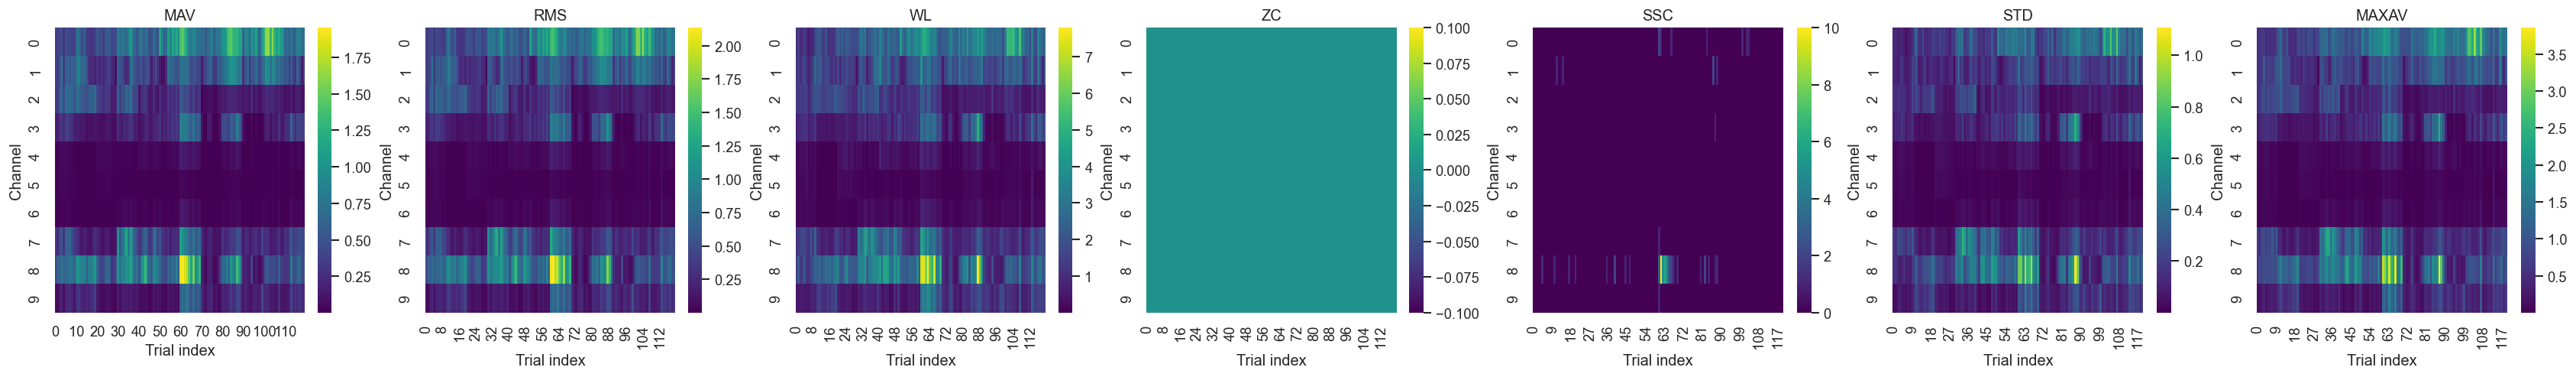

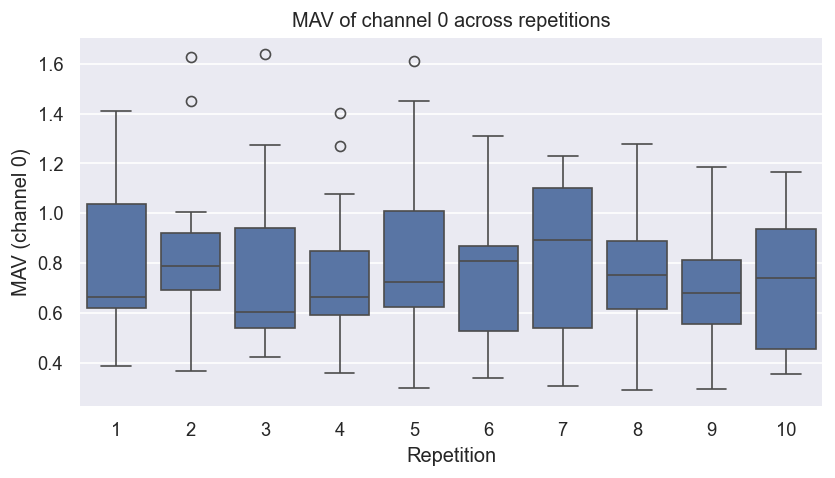

In [129]:
n_trials = X_features.shape[0]
n_channels = emg_clean.shape[1]
n_feat = len(feature_names)

# reshape: (trials, features, channels)
features_3d = X_features.reshape(n_trials, n_feat, n_channels)

# ---- 3a) Heatmaps: each feature separately ----
fig, axes = plt.subplots(1, n_feat, figsize=(4*n_feat, 4), constrained_layout=True)

if n_feat == 1:
    axes = [axes]

for fi, fname in enumerate(feature_names):
    # rows = channels, columns = trials
    data = features_3d[:, fi, :].T  # shape (channels, trials)
    sns.heatmap(data, ax=axes[fi], cmap="viridis", cbar=True)
    axes[fi].set_title(fname)
    axes[fi].set_xlabel("Trial index")
    axes[fi].set_ylabel("Channel")

plt.show()

# ---- 3b) Example boxplot: one feature, one channel, across repetitions ----
# Let's pick MAV of channel 0 as a simple example

# extract MAV block: first feature in feature_names -> index 0
mav_block = features_3d[:, feature_names.index("MAV"), :]  # shape (trials, channels)
mav_ch0   = mav_block[:, 0]

import pandas as pd

df_feat = pd.DataFrame({
    "MAV_ch0": mav_ch0,
    "action": y_features,
    "repetition": rep_ids_features,
})

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_feat, x="repetition", y="MAV_ch0")
plt.title("MAV of channel 0 across repetitions")
plt.xlabel("Repetition")
plt.ylabel("MAV (channel 0)")
plt.show()


Note: ZC is only 0 of course as we don't have 0 crossings for a rectified signal

## 4. Perform classification on the data of subject 2. Predict the action of the subject based  on the EMG signals. Use hyperparameter optimization to increase your models’ performance (Gradient boosting) 

In [130]:
# --- Global masks: which trials are in train/test reps? ---
trial_train_mask = np.isin(rep_ids_features, train_reps)
trial_test_mask  = np.isin(rep_ids_features, test_reps)

# Global indices of those trials
train_idx_global = np.where(trial_train_mask)[0]
test_idx_global  = np.where(trial_test_mask)[0]

# Now actually build X_train / X_test, y_train / y_test
X_train = X_features[train_idx_global]
y_train = y_features[train_idx_global]
rep_train = rep_ids_features[train_idx_global]

X_test  = X_features[test_idx_global]
y_test  = y_features[test_idx_global]
rep_test = rep_ids_features[test_idx_global]

print("Train trials:", X_train.shape[0])
print("Test trials: ", X_test.shape[0])


Train trials: 96
Test trials:  24


In [131]:
cv_trial_splits = []

for fold_idx, (reps_train_fold, reps_val_fold) in enumerate(cv_rep_splits):
    # indices within X_train for this fold
    fold_train_idx = np.where(np.isin(rep_train, reps_train_fold))[0]
    fold_val_idx   = np.where(np.isin(rep_train, reps_val_fold))[0]

    cv_trial_splits.append((fold_train_idx, fold_val_idx))

    print(f"Fold {fold_idx}:")
    print("  train reps:", reps_train_fold, "->", len(fold_train_idx), "train trials")
    print("  val reps  :", reps_val_fold,   "->", len(fold_val_idx),   "val trials")


Fold 0:
  train reps: [ 1  4  5  6  9 10] -> 72 train trials
  val reps  : [2 8] -> 24 val trials
Fold 1:
  train reps: [2 4 5 6 8 9] -> 72 train trials
  val reps  : [ 1 10] -> 24 val trials
Fold 2:
  train reps: [ 1  2  5  8  9 10] -> 72 train trials
  val reps  : [4 6] -> 24 val trials
Fold 3:
  train reps: [ 1  2  4  6  8 10] -> 72 train trials
  val reps  : [5 9] -> 24 val trials


In [132]:
gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators":  [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [2, 3],
    "subsample":     [1.0, 0.8],
}

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=cv_trial_splits,   # <-- now in X_train index space
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)


Fitting 4 folds for each of 36 candidates, totalling 144 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3], 'n_estimators': [50, 100, ...], 'subsample': [1.0, 0.8]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,"[(array([ 0, 2..., 92, 94, 95]), ...), (array([ 1, 2..., 92, 93, 94]), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


Evaluate best model on test set

Best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best CV accuracy: 0.8125

Test accuracy on repetitions [3 7]: 0.958


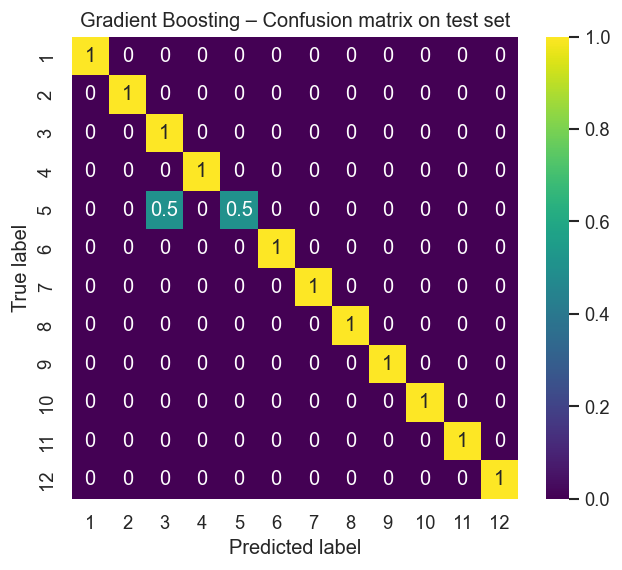

In [134]:
# Best model from GridSearchCV
best_gb = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# --- Evaluate on held-out test repetitions ---

y_pred_test = best_gb.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nTest accuracy on repetitions {test_reps}: {test_acc:.3f}")

# Confusion matrix (normalized by true class)
confmat = confusion_matrix(y_test, y_pred_test, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confmat, annot=True, cmap="viridis", ax=ax,
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting – Confusion matrix on test set")
plt.show()

## 5. Evaluate the performance using a metric of your choice. Justify why the metric is  suitable for this task and whether the performance is satisfactory.

In exercise 11 the print accuracy and show the confusion matrix 

TODO: check papers for best metric

## 6. Perform feature selection / dimension reduction using 2 methods of your choice that you think might perform better or yield insights.  Evaluate the performance using the same metric as point 5. Is there an improvement  in the performance and why do you think this is the case?

### Feature selection: Mutual Information + SelectKBest

You choose k manually (e.g., keep 20 out of 70 features). TODO check that

In [135]:
# ========== METHOD 1: Mutual Information + SelectKBest ==========

k_best = 20   # choose number of features to keep

# Build pipeline: feature selection + Gradient Boosting
pipe_kbest = Pipeline([
    ("select", SelectKBest(mutual_info_classif, k=k_best)),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_kbest = {
    "clf__n_estimators":  [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth":     [2, 3],
    "clf__subsample":     [1.0, 0.8],
}

grid_kbest = GridSearchCV(
    estimator=pipe_kbest,
    param_grid=param_grid_kbest,
    cv=cv_trial_splits,      # <-- repetition-wise CV
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_kbest.fit(X_train, y_train)

print("==== SelectKBest + MI ====")
print("Best CV accuracy:", grid_kbest.best_score_)
print("Best params:", grid_kbest.best_params_)

# Evaluate on held-out test set
# transform test set using the best selector found
X_test_sel = grid_kbest.best_estimator_.named_steps["select"].transform(X_test)
y_pred_test_sel = grid_kbest.best_estimator_.named_steps["clf"].predict(X_test_sel)

acc_test_sel = accuracy_score(y_test, y_pred_test_sel)
print("Test accuracy (SelectKBest):", acc_test_sel)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
==== SelectKBest + MI ====
Best CV accuracy: 0.78125
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Test accuracy (SelectKBest): 0.9583333333333334


In [138]:
selector = grid_kbest.best_estimator_.named_steps["select"]

print("Selected feature indices:")
print(selector.get_support(indices=True))


Selected feature indices:
[ 0  2  3  4  8 10 12 13 14 18 22 23 28 53 57 58 60 62 63 68]


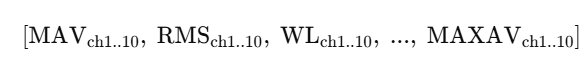

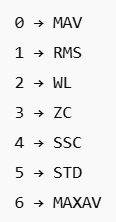

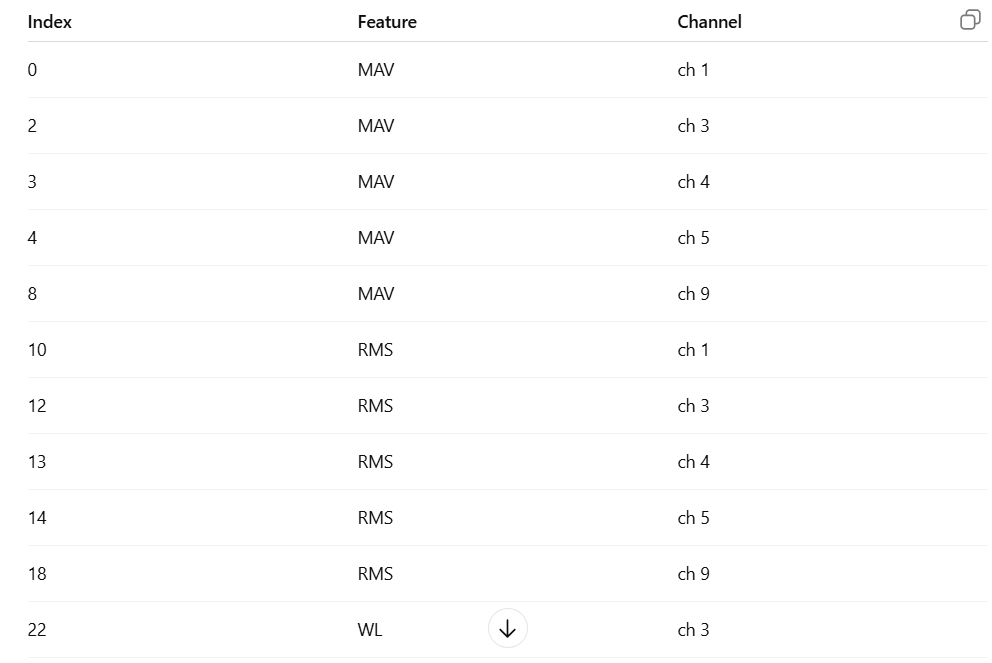

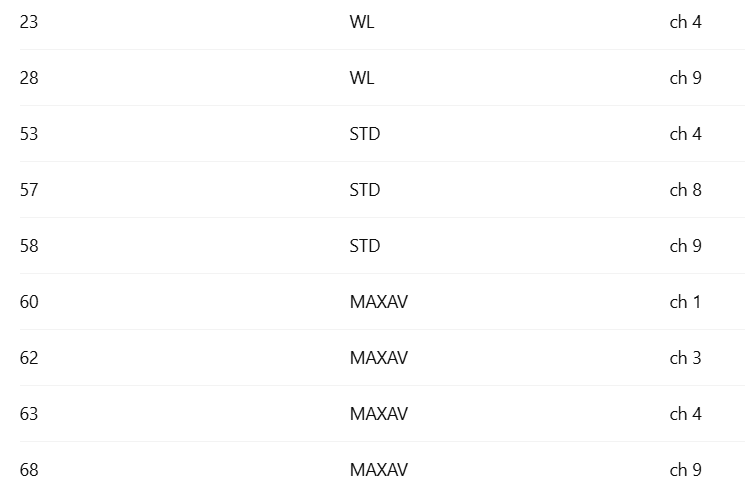

Do we have to normalize the features for Gradient Boosting? TODO

In [136]:
# ========== METHOD 2: PCA dimensionality reduction ==========

# PCA must be preceded by scaling for meaningful variance
pipe_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_pca = {
    "pca__n_components": [5, 10, 15, 20, 30],     # dimensionality choices
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3],
}

grid_pca = GridSearchCV(
    estimator=pipe_pca,
    param_grid=param_grid_pca,
    cv=cv_trial_splits,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_pca.fit(X_train, y_train)

print("==== PCA Reduction ====")
print("Best CV accuracy:", grid_pca.best_score_)
print("Best params:", grid_pca.best_params_)

# Evaluate on test set
y_pred_test_pca = grid_pca.best_estimator_.predict(X_test)
acc_test_pca = accuracy_score(y_test, y_pred_test_pca)

print("Test accuracy (PCA):", acc_test_pca)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
==== PCA Reduction ====
Best CV accuracy: 0.7291666666666667
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'pca__n_components': 10}
Test accuracy (PCA): 0.9166666666666666


ICA

In [137]:
# ========== METHOD 3: ICA dimensionality reduction ==========

pipe_ica = Pipeline([
    ("scaler", StandardScaler()),
    ("ica", FastICA(max_iter=1000, random_state=42)),
    ("clf", GradientBoostingClassifier(random_state=42)),
])

param_grid_ica = {
    "ica__n_components": [5, 10, 15, 20, 30],  # number of ICs to keep
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3],
}

grid_ica = GridSearchCV(
    estimator=pipe_ica,
    param_grid=param_grid_ica,
    cv=cv_trial_splits,   # repetition-wise CV
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_ica.fit(X_train, y_train)

print("==== ICA Reduction ====")
print("Best CV accuracy:", grid_ica.best_score_)
print("Best params:", grid_ica.best_params_)

# --- Evaluate on test set ---
y_pred_test_ica = grid_ica.best_estimator_.predict(X_test)
test_acc_ica = accuracy_score(y_test, y_pred_test_ica)

print("Test accuracy (ICA):", test_acc_ica)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
==== ICA Reduction ====
Best CV accuracy: 0.7604166666666666
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'ica__n_components': 10}
Test accuracy (ICA): 0.875
